---
numbering:
  title: false
  headings: false
---

(sec:project_manganate_decay)=

# Fitting absorbance data for the decay of tris(oxalato)manganate(III)


Das Ziel dieses Projekt ist es, unsere Daten vom Versuch Manganzerfall aus dem PCP durch realisitischere nicht-lineare Modelle zu fitten. Dadurch soll zum einem der Fehler nicht verzerrt werden, zum anderen kann so eine Hintergrundkorrektur einfach miteinbezogen werden. So können präzisere Werte bestimmt werden, als mit einem linearen Fit.
Die zugrundeliegende Reaktion ist hierbei:

$$
[\text{Mn}(\text{C}_2\text{O}_4)_3]^{3-} \rightarrow \text{Mn}^{2+} + \frac{5}{2} \ \text{C}_2\text{O}_4^{2-} + \text{CO}_2
$$

Die folgenden Modelle haben wir mithilfe von Optimierung (Minimierung) und Regression gefittet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize

## Unsere Daten:

Die Absorptionsdaten können hier heruntergeladen werden: {download}`/assets/data/projects/Mn_20.csv`, {download}`/assets/data/projects/Mn_30.csv`, {download}`/assets/data/projects/Mn_40.csv` und {download}`/assets/data/projects/Mn_50.csv`.

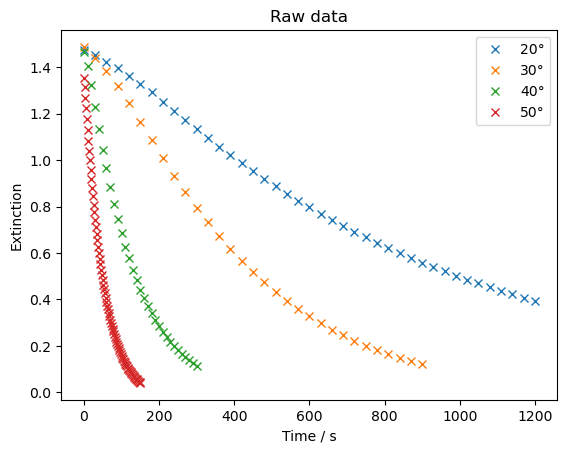

In [2]:
df20 = pd.read_csv("../../assets/data/projects/Mn_20.csv")
df30 = pd.read_csv("../../assets/data/projects/Mn_30.csv")
df40 = pd.read_csv("../../assets/data/projects/Mn_40.csv")
df50 = pd.read_csv("../../assets/data/projects/Mn_50.csv")

data = {
    "20°": df20,
    "30°": df30,
    "40°": df40,
    "50°": df50
}

colors = { 
    "20°": "C0",
    "30°": "C1",
    "40°": "C2",
    "50°": "C3"
} 

for label, df in data.items():
    
    x = df["time /s"].values
    y = df["extinction"].values
    
    plt.plot(x, y, 'x', label= label)

plt.xlabel('Time / s')
plt.ylabel('Extinction')
plt.legend()
plt.title('Raw data')
plt.show()

## Linearer fit

$$
ln(A) = - kt + ln(A_0)
$$


20°: k = 0.0011, A0 = 1.570582
30°: k = 0.0029, A0 = 1.780587
40°: k = 0.0087, A0 = 1.600547
50°: k = 0.0231, A0 = 1.499666


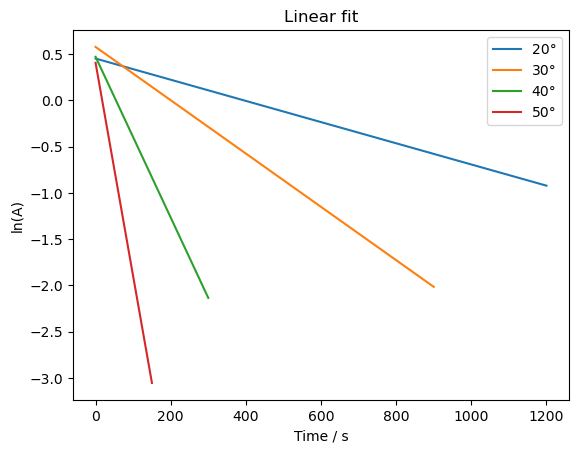

In [3]:
k_lin_arr = []
for label, df in data.items():
    
    x = df["time /s"].values
    y = np.log(df["extinction"].values) 

    k_lin, c = np.polyfit(x, y, 1) #lineare Gleichung mit unseren Variablen (Dimension = 1)
    x_lin = np.linspace(np.min(x),np.max(x), 1000) 
    linear_fit = k_lin * x_lin + c 
    k_lin_arr.append(-k_lin) 
    a0 = np.exp(c)
    
    print(f"{label}: k = {- k_lin:.4f}, A0 = {a0:.6f}") 
    plt.plot(x_lin, linear_fit, '-', label= label)
    plt.xlabel('Time / s')
    plt.ylabel('ln(A)')
    plt.title('Linear fit')
    plt.legend()
  

Die Steigung liefert direkt k, durch Logarithmieren werden aber mögliche Messfehler stärker gewichtet.

### Arrhenius Gleichung:

$$
k = A \exp\left(-\frac{E_\mathrm{a}}{RT}\right)
$$

Linear : 
$$
ln(k) = ln(A) -\frac{E_\mathrm{a}}{RT}
$$


In [4]:
R = 8.314  # J/(mol K)
T = np.array([293.15, 303.15, 313.15, 323.15])

def linear_arrhenius(k, T): 
    x = 1 / T
    y = np.log(k)
    params = np.polyfit(x, y, 1) #lineare Regression
    Ea = -(params[0] * R) #params[0] ist die Steigung
    A = np.exp(params[1])
    
    x_grid = np.linspace(max(T), min(T), 100) 
    y_fit = params[1] - params[0]/x_grid  
    plt.plot(x_grid, y_fit, '-')
    plt.xlabel('1/T in 1/K ')
    plt.ylabel('ln(k)')
    plt.show()

    return Ea, A

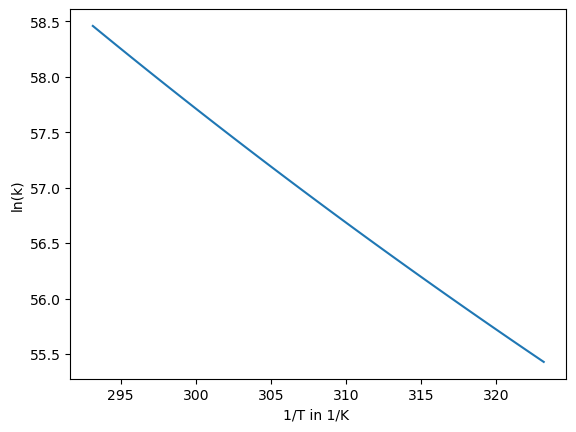

Ea= 79565.65414560065 J/mol
A= 162341047805.4195 1/s


In [5]:
Ea_lin, A_lin = linear_arrhenius(k_lin_arr, T)
print('Ea=',Ea_lin, 'J/mol')
print('A=', A_lin, '1/s')

## Exponentieller fit
$$
A(t) =A_0 \exp(-kt),
$$
Minimierung des Fehlers für den exponetial fit mit scipy.optimize.minimize

In [6]:
def exponential_loss(theta, x, y):
    a0, k = theta  #theta[0] -> A0 ; theta[1] -> k 
    y_fit = a0 * np.exp(-k * x)
    return np.sum((y_fit - y) ** 2) #gibt direkt den Fehler aus 

results_exp = {} 
k_exp = [] 

for label, df in data.items():

    x = df["time /s"].values
    y = df["extinction"].values

    result_exp = minimize( 
        exponential_loss,
        x0=np.array([y[0], 0.002]), #Startwerte: A0 erster Messwert
        args=(x, y),
        method="Nelder-Mead",
        options={"maxiter": 20000}
    )
    results_exp[label] = result_exp 
    a0, k = result_exp.x
    k_exp.append(k) 
    print(f"{label}: A0 = {a0:.4f}, k = {k:.6f}")

20°: A0 = 1.5489, k = 0.001114
30°: A0 = 1.6201, k = 0.002539
40°: A0 = 1.5416, k = 0.008261
50°: A0 = 1.3949, k = 0.021415


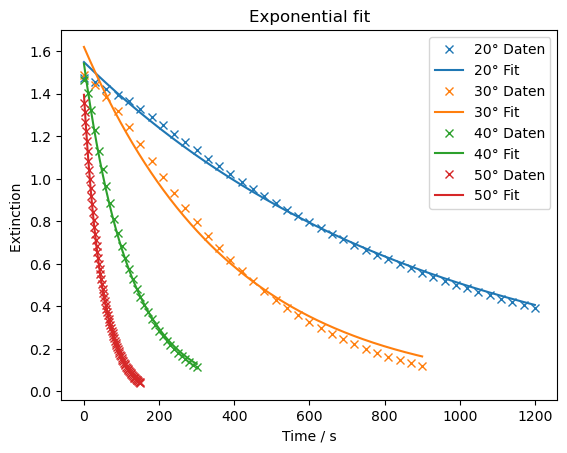

In [7]:
for label, df in data.items():

    x = df["time /s"].values
    y = df["extinction"].values
    
    color = colors[label] #oben definierte Farben
    
    plt.plot(x, y, 'x', label=f'{label} Daten', color=color)

    a0, k = results_exp[label].x
    x_fit = np.linspace(x.min(), x.max(), 500) 
    y_fit = a0 * np.exp(-k * x_fit) #Berechnung der Extinktion 

    plt.plot(x_fit, y_fit, label=f'{label} Fit', color=color)

plt.xlabel('Time / s')
plt.ylabel('Extinction ')
plt.legend()
plt.title('Exponential fit')
plt.show()

Bessere Anpassung an die Rohdaten; realistischere Fehlergewichtung, weil Fehler nicht durch Logarithmus verzerrt wird

Achtung:
$
A ≠ A_0
$ 

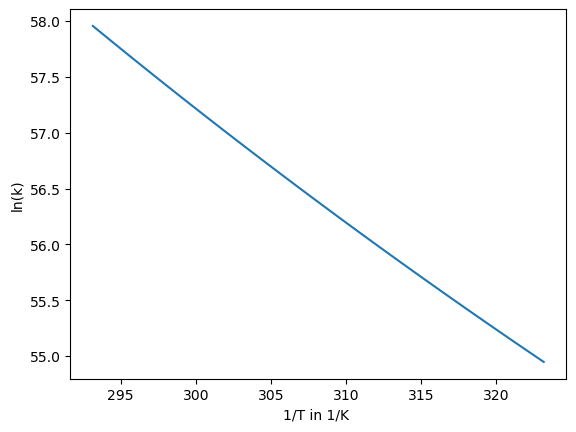

Ea= 79025.68265713459 J/mol
A= 122638015444.1178 1/s


In [8]:
Ea_exp, A_exp = linear_arrhenius(k_exp, T)
print('Ea=',Ea_exp, 'J/mol')
print('A=', A_exp, '1/s')

Andere Möglichkeit: mit $ A_\infty $ eine Hintergrund Korrekur miteinbeziehen

$$
A(t) = (A_0 - A_\infty) \exp(-kt) + A_\infty
$$


Zunächst fitten wir  $ A_\infty $ für jede Temperatur einzeln

In [9]:
def exponential_correction_loss(beta, x, y): #selbe Implementierung wie oben nur mit A_inf
    a0, a_inf, k = beta 
    y_fit = (a0 - a_inf) * np.exp(-k * x) + a_inf
    return np.sum((y_fit - y) ** 2)

results_expcor = {} 
k_expcor = []

for label, df in data.items():

    x = df["time /s"].values
    y = df["extinction"].values

    result_expcor = minimize(
        exponential_correction_loss,
        x0=np.array([y[0], y[-1], 0.002]), #Startwerte: für A0 den ersten Messwert, für A_inf den letzten Messwert
        args=(x, y),
        method="Nelder-Mead",
        options={"maxiter": 20000}
    )
    results_expcor[label] = result_expcor
    a0, a_inf, k = result_expcor.x
    k_expcor.append(k)
    
    print(f"{label}: A0 = {a0:.4f}, A∞ = {a_inf:.4f}, k = {k:.6f}")

20°: A0 = 1.5234, A∞ = -0.2599, k = 0.000857
30°: A0 = 1.5645, A∞ = -0.2603, k = 0.001837
40°: A0 = 1.5195, A∞ = -0.0725, k = 0.007384
50°: A0 = 1.3788, A∞ = -0.0323, k = 0.020026


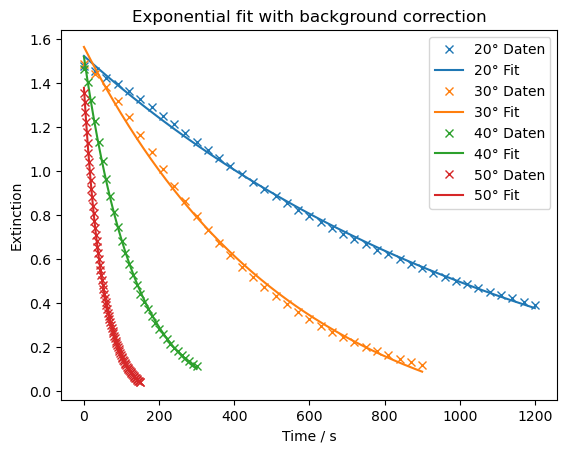

In [10]:
for label, df in data.items():

    x = df["time /s"].values
    y = df["extinction"].values
    
    color = colors[label]
    
    plt.plot(x, y, 'x', label=f'{label} Daten', color=color)

    a0, a_inf, k = results_expcor[label].x
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = (a0 - a_inf) * np.exp(-k * x_fit) + a_inf

    plt.plot(x_fit, y_fit, label=f'{label} Fit', color=color)

plt.xlabel('Time / s')
plt.ylabel('Extinction')
plt.legend()
plt.title('Exponential fit with background correction')
plt.show()

Berücksichtigt Restabsorptionen, die in der Praxis immer auftreten (durch Küvette, Lösungsmittel etc.)

$\rightarrow $ deutlich bessere Beschreibung der Daten, als die bisherigen Modelle

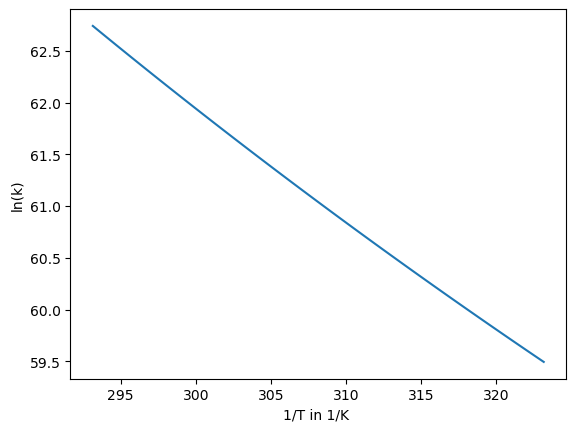

Ea= 85235.50101945733 J/mol
A= 1147232202128.102 1/s


In [11]:
Ea_expcor, A_expcor = linear_arrhenius(k_expcor, T)
print('Ea=',Ea_expcor, 'J/mol')
print('A=', A_expcor, '1/s')

Jetzt mit einem  $ A_\infty $ für alle Temperaturen

In [12]:
labels = list(data.keys()) #erstellen einer normalen Python_liste
N = len(labels) #zählt, wie viele Temp. 

def global_exponential_loss(params, data, labels):
    loss = 0.0 #Fehlersumme wird gestartet, wird später aufaddiert 

    a_inf = params[-1] #initial guess: letzter Wert im Parameterarray = der Wert, gegen den alle fits laufen werden

    for i, label in enumerate(labels):

        a0 = params[2 * i] #anfangswert a0 bzw. k einer jeden Temperatur
        k  = params[2 * i + 1] #jede Temperatur besitzt zwei Parameter: params[0] = a0(20 grad), params[1] = k(20 grad) ...

        x = data[label]["time /s"].values
        y = data[label]["extinction"].values

        y_fit = (a0 - a_inf) * np.exp(-k * x) + a_inf 

        loss += np.sum((y_fit - y) ** 2) 
        
    return loss

x0 = [] 

for label in labels:

    y = data[label]["extinction"].values

    a0_guess = y[0] 
    k_guess = 0.002

    x0.extend([a0_guess, k_guess]) #speichert beide Parameter in Liste

a_inf_guess = np.mean(
    [df["extinction"].values[-1] for df in data.values()]
) #inital guess: Mittelwert der letzten Messpunkte

x0.append(a_inf_guess)

bounds_inf = [] #Liste für erlaubte Parameterbereiche

for _ in range(N):
    bounds_inf.append((1e-10, None))   # A0 > 0
    bounds_inf.append((1e-10, None))   # k, wenn k < 0, wäre es kein Zerfall, sonder Wachstum: physikalisch unlogisch

bounds_inf.append((None, None))    #A_inf    

result = minimize(
    global_exponential_loss,
    x0=np.array(x0),
    args=(data, labels),
    method="L-BFGS-B", #einzige Methode, die Bounds erlaubt
    bounds=bounds_inf
)


params = result.x
a_inf = params[-1] #der letzte gespeicherte Parameter ist A_inf

k_global = []

print(f"\nGemeinsames A_inf = {a_inf:.6f}\n")

for i, label in enumerate(labels):

    a0 = params[2 * i]
    k = params[2 * i + 1]
    k_global.append(k)

    print(f"{label}: A0 = {a0:.6f}, k = {k:.6f}")


Gemeinsames A_inf = -0.064455

20°: A0 = 1.541558, k = 0.001037
30°: A0 = 1.606059, k = 0.002328
40°: A0 = 1.519582, k = 0.007461
50°: A0 = 1.363032, k = 0.018766


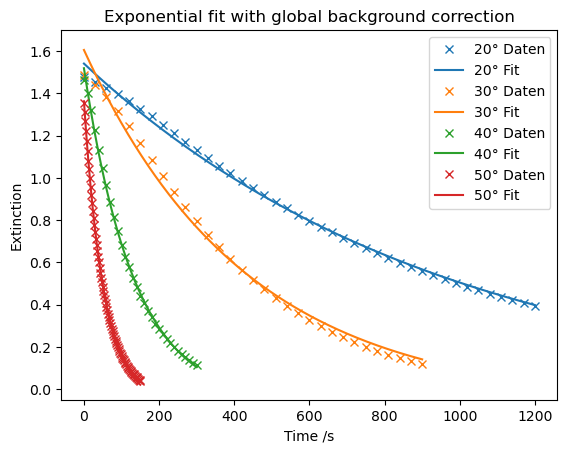

In [13]:
a_inf = result.x[-1]


for i, label in enumerate(labels):

    df = data[label]

    x = df["time /s"].values
    y = df["extinction"].values

    a0 = result.x[2 * i]
    k  = result.x[2 * i + 1]

    color = colors[label]

    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = (a0 - a_inf) * np.exp(-k * x_fit) + a_inf

    plt.plot(x, y, "x", color=color, label=f"{label} Daten")
    plt.plot(x_fit, y_fit, color=color, label=f"{label} Fit")

plt.xlabel("Time /s")
plt.ylabel("Extinction")
plt.ylim(-0.05, 1.7)
plt.legend()
plt.title('Exponential fit with global background correction')
plt.show()

global background correction liefert schlechteren Fit als der Fit mit einzelnen seperaten background corrections

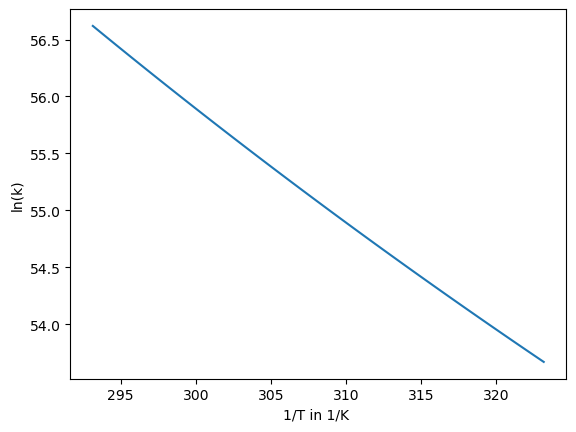

Ea= 77479.34356345047 J/mol
A= 60757299110.91509 1/s


In [14]:
Ea_global, A_global = linear_arrhenius(k_global, T)
print('Ea=',Ea_global, 'J/mol')
print('A=', A_global, '1/s')

## Doppelt Exponentieller Zerfall mit zwei Koeffizienten
$$
A(t) = C_1 \exp(-k_1 t) + C_2 \exp(-k_2 t).
$$
Der Zerfall des Mangan Komplexes könnte evt. durch zwei getrennt Zerfallsreaktionen beschrieben werden 

In [15]:
def double_exponential_loss(gamma, x, y):
    c1, c2, k1, k2 = gamma 
    y_fit = c1 * np.exp(-k1 * x) + c2 * np.exp(-k2 * x)
    return np.sum((y_fit - y) ** 2)

results_dexp = {}
k1_dexp = []
k2_dexp = []

bounds_dexp = [ 
    (0, None),  # c1 > 0 
    (0, None),  # c2 > 0
    (0, None),  # k1 > 0 
    (0, None)   # k2 > 0
]

for label, df in data.items():

    x = df["time /s"].values
    y = df["extinction"].values

    result_dexp = minimize(
        double_exponential_loss,
        x0=np.array([y[0]/2, y[0]/2, 0.02, 0.001]), #initial guess
        args=(x, y),
        method="L-BFGS-B",
        bounds=bounds_dexp 
    )

    results_dexp[label] = result_dexp 
    c1, c2, k1, k2 = result_dexp.x 

    k1_dexp.append(k1) 
    k2_dexp.append(k2)
    
    print(f"{label}: C1 = {c1:.4f}, C2 = {c2:.4f}, k1 = {k1:.6f}, k2 = {k2:.6f}")

20°: C1 = 0.5381, C2 = 1.0107, k1 = 0.001114, k2 = 0.001114
30°: C1 = 0.7666, C2 = 0.8535, k1 = 0.002539, k2 = 0.002539
40°: C1 = 0.7709, C2 = 0.7708, k1 = 0.008261, k2 = 0.008261
50°: C1 = 0.8742, C2 = 0.5207, k1 = 0.021414, k2 = 0.021414


Je nach Startwert für C1 und C2 sind entweder die Werte k1 und k2 fast identisch oder eines der beiden C wird annähernd 0
 
 $\rightarrow $ spricht gegen die Theorie eines doppelten exponentiellen Zerfalls

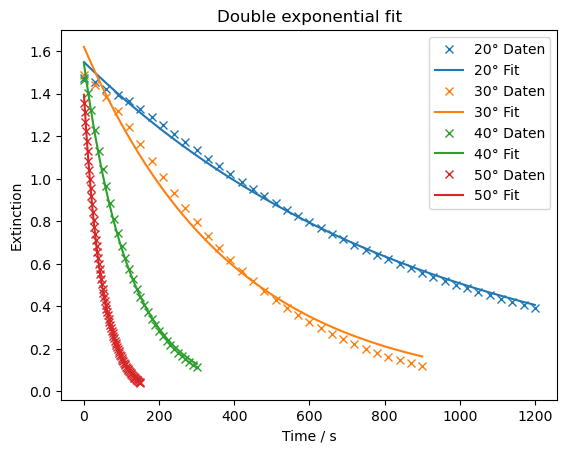

In [16]:
for label, df in data.items():

    x = df["time /s"].values
    y = df["extinction"].values
    
    color = colors[label]
    
    plt.plot(x, y, 'x', label=f'{label} Daten', color=color)

    c1, c2, k1, k2 = results_dexp[label].x
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = c1 * np.exp(- k1 * x_fit) +  c2 * np.exp(- k2 * x_fit)

    plt.plot(x_fit, y_fit, label=f'{label} Fit', color=color)

plt.xlabel('Time / s')
plt.ylabel('Extinction')
plt.legend()
plt.title('Double exponential fit')
plt.show()


k1: [np.float64(0.001113795100502611), np.float64(0.002538907935169712), np.float64(0.008260835094496485), np.float64(0.021414156593910178)]
k2: [np.float64(0.0011135961151176356), np.float64(0.0025389005204221977), np.float64(0.008260835536556432), np.float64(0.02141425376045388)]


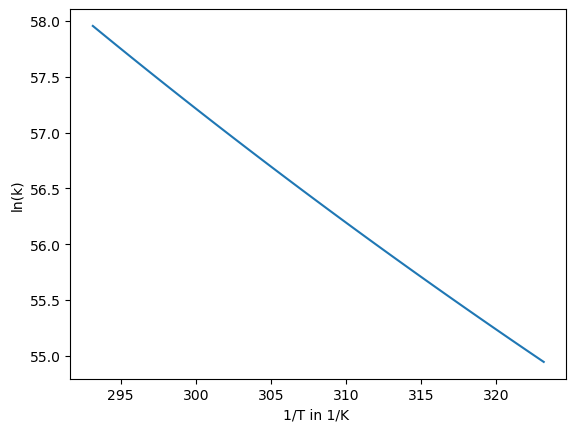

Ea= 79024.03979703634 J/mol
A= 122560276654.9713 1/s


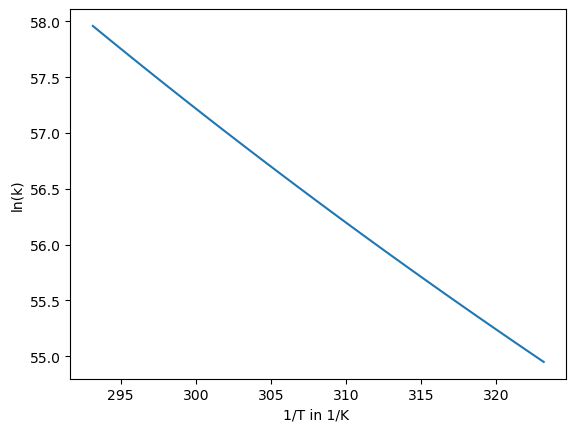

Ea= 79028.47770812745 J/mol
A= 122767611599.80438 1/s


In [17]:
print('k1:', k1_dexp)
print('k2:', k2_dexp)

Ea1_dexp, A1_dexp = linear_arrhenius(k1_dexp, T)
print('Ea=',Ea1_dexp, 'J/mol')
print('A=', A1_dexp, '1/s')

Ea2_dexp, A2_dexp = linear_arrhenius(k2_dexp, T)
print('Ea=',Ea2_dexp, 'J/mol')
print('A=', A2_dexp, '1/s')

In [18]:
Ea_dexp = (Ea1_dexp + Ea2_dexp) / 2
print(Ea_dexp)

79026.2587525819


Ea und A unterscheiden sich nahezu nicht, was auch dagegen spricht, dass es sich um zwei unterschiedliche Zerfallsprozesse handelt. Sorgt wegen Überparametrisierung eher dafür, dass der Fit sehr empfindlich auf die Startwerte reagiert. 

## Ergebnisse

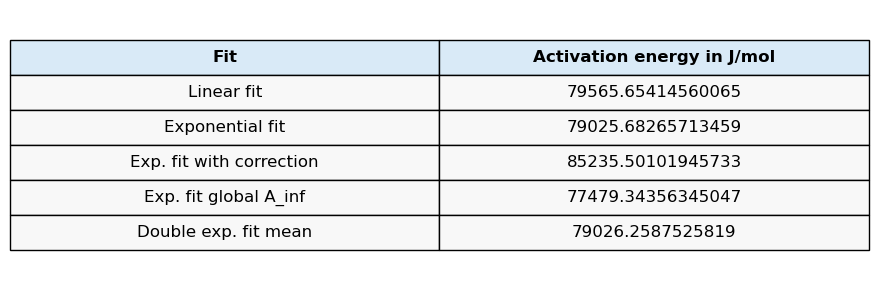

In [19]:
all_results = {
    'Fit': ['Linear fit', 'Exponential fit', 'Exp. fit with correction', 
            'Exp. fit global A_inf', 'Double exp. fit mean' ],
    'Activation energy in J/mol': [Ea_lin, Ea_exp, Ea_expcor, Ea_global, Ea_dexp]
}

df = pd.DataFrame(all_results)

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')

tabelle = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

# Schriftgröße
tabelle.auto_set_font_size(False)
tabelle.set_fontsize(12)

# Zellgröße (Breite, Höhe)
tabelle.scale(1.3, 1.8)

# Styling
for (row, col), cell in tabelle.get_celld().items():
    cell.set_edgecolor('black')
    
    # Kopfzeile
    if row == 0:
        cell.set_facecolor('#D9EAF7')
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('#F8F8F8')

plt.tight_layout()
plt.show()

Fazit: 
- double exponential fit und exponential fit sind nahezu gleich
- exponetial fit with correction sticht hervor durch höchsten Wert

## Offene Fragen

- Optimale Startwerte finden (vor allem Doppelt Exponentieller Zerfall)
- Arrhenius Gleichung ebenfalls mit Loss Funktion minimieren -> haben wir versucht, aber hat nicht so gut funktionert mit scipy